In [57]:
from simulator import Config, Simulator

config = Config()
config.NODE_POWER_W = 0.02  # Node power consumption in kW
simulator = Simulator(config)

# CSV including time series data for production (G(h) in kWh, and Temperature in °C)
production_data = "raw-data/CR.csv"

In [58]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import plotly.express as px
import plotly.graph_objects as go

## Run Complete Simulation

This single function call executes the entire pipeline:
1. Load irradiance data
2. Compute PV power for all panel sizes
3. Compute hourly power balance with PMU efficiency
4. Simulate battery State of Charge for all configurations
5. Evaluate viability and compute scores

In [59]:
# Run the full simulation
results = simulator.run_full_simulation(production_data)

# Extract results
df_pv = results['df_pv']
df_pv_pmu = results['df_pv_pmu']
df_soc = results['df_soc']
summary = results['summary']

Loading irradiance data...
Computing PV power...
Computing hourly balance...
Simulating battery SoC...
Evaluating viability...
Computing optimal scores...
Done!


## Design space

In [60]:
df_design = simulator.build_design_space()
df_design

,panel_area_m2,battery_capacity_Ah,eta_PMU
0,0.0001,0.105,0.87
1,0.0001,0.105,0.90
2,0.0001,0.105,0.95
3,0.0001,0.105,0.98
4,0.0001,0.350,0.87
...,...,...,...
667,0.0400,3.200,0.98
668,0.0400,2.300,0.87
669,0.0400,2.300,0.90
670,0.0400,2.300,0.95


## Explore Results

In [61]:
print("Top 10 configurations by score:")
summary.head(10)

Top 10 configurations by score:


,panel_area_m2,C_batt_Ah,eta_PMU,hours_total,hours_soc_min,hours_soc_full,soc_mean,soc_std,surplus_Ah,deficit_Ah,autonomy_hours,failure_hours,I_batt_max_A,I_req_max_A,soc_min_fraction,soc_full_fraction,net_Ah,score
0,0.00250,0.35,0.95,8760,0,2708,0.911947,0.093480,26.617772,140.350912,8760,0,0.525,0.091836,0.0,0.309132,-113.733140,0.620230
1,0.00250,0.35,0.98,8760,0,2795,0.917280,0.087579,25.762456,149.999096,8760,0,0.525,0.097895,0.0,0.319064,-124.236640,0.620230
2,0.00250,0.40,0.87,8760,0,2407,0.903911,0.104190,29.205400,116.197616,8760,0,0.600,0.076624,0.0,0.274772,-86.992216,0.614845
3,0.00250,0.40,0.90,8760,0,2544,0.912359,0.093973,28.177673,124.986476,8760,0,0.600,0.082167,0.0,0.290411,-96.808803,0.614845
4,0.00250,0.40,0.98,8760,0,2795,0.927620,0.076631,25.762456,149.999096,8760,0,0.600,0.097895,0.0,0.319064,-124.236640,0.614845
5,0.00250,0.40,0.95,8760,0,2708,0.922954,0.081795,26.617772,140.350912,8760,0,0.600,0.091836,0.0,0.309132,-113.733140,0.614845
6,0.00625,0.12,0.98,8760,0,3616,0.808349,0.216040,24.914967,406.676905,8760,0,0.240,0.252683,0.0,0.412785,-381.761938,0.613673
7,0.00250,0.42,0.90,8760,0,2544,0.916533,0.089498,28.177673,124.986476,8760,0,0.630,0.082167,0.0,0.290411,-96.808803,0.612691
8,0.00250,0.42,0.87,8760,0,2407,0.908486,0.099229,29.205400,116.197616,8760,0,0.630,0.076624,0.0,0.274772,-86.992216,0.612691
9,0.00250,0.42,0.98,8760,0,2795,0.931067,0.072982,25.762456,149.999096,8760,0,0.630,0.097895,0.0,0.319064,-124.236640,0.612691


## Plot best configurations

Visualize all configurations in 3D space (panel area × battery capacity × PMU efficiency)

In [62]:
LOG_COLOR = False

data = summary.copy()

if LOG_COLOR:
    eps = 1e-9
    data["score_color"] = np.log10(data["score"] + eps)
    color_label = "log10(score)"
else:
    data["score_color"] = data["score"]
    color_label = "score"

fig = px.scatter_3d(
    data,
    x="panel_area_m2",
    y="C_batt_Ah",
    z="eta_PMU",
    color="score_color",
    labels={
        "panel_area_m2": "Panel area (m²)",
        "C_batt_Ah": "Battery (Ah)",
        "eta_PMU": "PMU efficiency",
        "score_color": color_label
    },
    opacity=0.85
)

fig.update_layout(
    width=1000,
    height=800,
    title=f"All configurations ({'log color scale' if LOG_COLOR else 'linear color scale'})"
)

fig.show()

## Score Distribution Histogram

In [63]:
fig = px.histogram(
    summary,
    x="score",
    nbins=50,
    labels={"score": "score"},
    opacity=0.85,
)

fig.update_layout(
    width=900,
    height=500,
    title="Score distribution",
    bargap=0.05
)

fig.show()

## Score at Maximum PMU Efficiency (not best configs)

In [64]:
eta_max = summary["eta_PMU"].max()
df_plane = summary[summary["eta_PMU"] == eta_max].copy()

df_pivot = (
    df_plane
    .pivot_table(
        index="C_batt_Ah",
        columns="panel_area_m2",
        values="score",
        aggfunc="mean"
    )
    .sort_index()
    .sort_index(axis=1)
)

X = df_pivot.columns.values
Y = df_pivot.index.values
X_grid, Y_grid = np.meshgrid(X, Y)
Z = df_pivot.values

fig = go.Figure(
    data=[
        go.Surface(
            x=X_grid,
            y=Y_grid,
            z=Z,
            colorscale="Viridis",
            colorbar={"title": "Score"}
        )
    ]
)

fig.update_layout(
    title=f"Score surface for max η_PMU ({eta_max})",
    scene=dict(
        xaxis_title="Panel area (m²)",
        yaxis_title="Battery capacity (Ah)",
        zaxis_title="Score"
    ),
    width=900,
    height=700
)

fig.show()

## Custom Analysis

You can also access individual simulation steps for custom analysis:

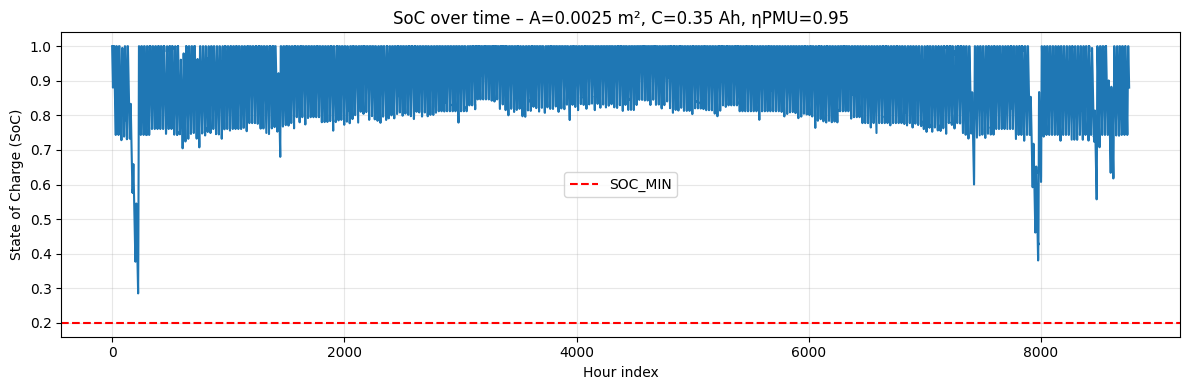

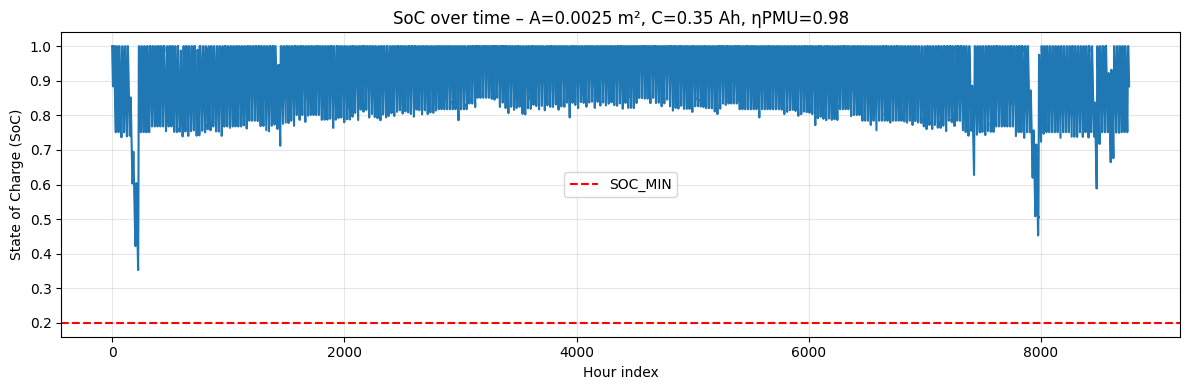

In [65]:
# Example: Analyze a specific configuration's SoC over time
best_configs = summary[summary["score"] == summary["score"].max()]

for _, cfg in best_configs.iterrows():
    config_soc = df_soc[
        (df_soc['panel_area_m2'] == cfg['panel_area_m2']) &
        (df_soc['C_batt_Ah'] == cfg['C_batt_Ah']) &
        (df_soc['eta_PMU'] == cfg['eta_PMU'])
    ].copy()

    plt.figure(figsize=(12, 4))
    plt.plot(config_soc['hour_index'], config_soc['SoC'])
    plt.axhline(y=Config.SOC_MIN, color='r', linestyle='--', label='SOC_MIN')
    plt.xlabel('Hour index')
    plt.ylabel('State of Charge (SoC)')
    plt.title(
        f"SoC over time – A={cfg['panel_area_m2']} m², "
        f"C={cfg['C_batt_Ah']} Ah, ηPMU={cfg['eta_PMU']}"
    )
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()


## Summary statistics

In [66]:
print("\n=== Simulation Summary ===")
print(f"Total configurations evaluated: {len(summary)}")
print(f"Configurations with zero failures: {len(summary[summary['failure_hours'] == 0])}")
print(f"Best score achieved: {summary['score'].max():.4f}")
print(f"Configurations with best score: {len(summary[summary['score'] == summary['score'].max()])}")


=== Simulation Summary ===
Total configurations evaluated: 672
Configurations with zero failures: 372
Best score achieved: 0.6202
Configurations with best score: 2


## Invalidad configs due to < SoC_min

In [67]:
invalid_soc = summary[summary["failure_hours"] > 0][[
    "panel_area_m2",
    "C_batt_Ah",
    "eta_PMU",
    "failure_hours",
    "autonomy_hours",
    "I_batt_max_A",
    "I_req_max_A"
]].sort_values("failure_hours", ascending=False)

invalid_soc


,panel_area_m2,C_batt_Ah,eta_PMU,failure_hours,autonomy_hours,I_batt_max_A,I_req_max_A
470,0.00010,0.105,0.90,8745,15,0.1575,0.006006
462,0.00010,0.105,0.87,8745,15,0.1575,0.006213
460,0.00010,0.105,0.95,8744,16,0.1575,0.005690
459,0.00010,0.105,0.98,8743,17,0.1575,0.005516
458,0.00010,0.120,0.87,8743,17,0.2400,0.006213
...,...,...,...,...,...,...,...
527,0.00250,0.350,0.90,3,8535,0.5250,0.082167
387,0.02500,0.120,0.90,2,7855,0.2400,0.865456
471,0.03100,0.120,0.90,2,7855,0.2400,1.074333
457,0.04000,0.120,0.90,2,7855,0.2400,1.387649


## Invalid configs due I_req > I_batt_max

In [68]:
invalid_peak = summary[
    summary["I_req_max_A"] > summary["I_batt_max_A"]
][[
    "panel_area_m2",
    "C_batt_Ah",
    "eta_PMU",
    "I_req_max_A",
    "I_batt_max_A",
    "failure_hours",
    "autonomy_hours"
]].sort_values("I_req_max_A", ascending=False)

invalid_peak


,panel_area_m2,C_batt_Ah,eta_PMU,I_req_max_A,I_batt_max_A,failure_hours,autonomy_hours
246,0.04000,0.120,0.98,1.645777,0.2400,0,8760
363,0.04000,2.500,0.98,1.645777,1.5000,0,8760
323,0.04000,1.200,0.98,1.645777,1.2000,0,8760
274,0.04000,0.420,0.98,1.645777,0.6300,0,8760
286,0.04000,0.500,0.98,1.645777,0.5000,0,8760
...,...,...,...,...,...,...,...
586,0.00625,0.105,0.98,0.252683,0.1575,94,5831
587,0.00625,0.105,0.95,0.237292,0.1575,106,5231
577,0.00625,0.105,0.90,0.212715,0.1575,234,4629
547,0.00625,0.105,0.87,0.198614,0.1575,368,4557


In [69]:
summary["autonomy_hours"].describe()


count     672.000000
mean     6010.389881
std      3589.164007
min        15.000000
25%      2022.750000
50%      8760.000000
75%      8760.000000
max      8760.000000
Name: autonomy_hours, dtype: float64

In [70]:
summary.sort_values("autonomy_hours").head(5)


,panel_area_m2,C_batt_Ah,eta_PMU,hours_total,hours_soc_min,hours_soc_full,soc_mean,soc_std,surplus_Ah,deficit_Ah,autonomy_hours,failure_hours,I_batt_max_A,I_req_max_A,soc_min_fraction,soc_full_fraction,net_Ah,score
470,0.00010,0.105,0.90,8760,8745,1,0.200684,0.019175,45.463043,-0.000000,15,8745,0.1575,0.006006,0.998288,0.000114,45.463043,0.0
462,0.00010,0.105,0.87,8760,8745,1,0.200659,0.018856,47.277271,-0.000000,15,8745,0.1575,0.006213,0.998288,0.000114,47.277271,0.0
460,0.00010,0.105,0.95,8760,8744,1,0.200726,0.019704,42.693958,-0.000000,16,8744,0.1575,0.005690,0.998174,0.000114,42.693958,0.0
603,0.00025,0.105,0.87,8760,7203,1,0.207732,0.028268,38.681604,1.611203,17,7203,0.1575,0.006213,0.822260,0.000114,37.070401,0.0
459,0.00010,0.105,0.98,8760,8743,1,0.200751,0.020020,41.168136,-0.000000,17,8743,0.1575,0.005516,0.998059,0.000114,41.168136,0.0


In [71]:
summary.sort_values("autonomy_hours").tail(5)

,panel_area_m2,C_batt_Ah,eta_PMU,hours_total,hours_soc_min,hours_soc_full,soc_mean,soc_std,surplus_Ah,deficit_Ah,autonomy_hours,failure_hours,I_batt_max_A,I_req_max_A,soc_min_fraction,soc_full_fraction,net_Ah,score
20,0.0040,0.4,0.87,8760,0,3023,0.924351,0.078937,28.578651,196.895865,8760,0,0.6,0.125420,0.0,0.345091,-168.317213,0.602314
19,0.0040,0.4,0.90,8760,0,3111,0.928815,0.074457,27.592642,211.379867,8760,0,0.6,0.134387,0.0,0.355137,-183.787226,0.602314
18,0.0025,0.5,0.95,8760,0,2708,0.938363,0.065436,26.617772,140.350912,8760,0,0.5,0.091836,0.0,0.309132,-113.733140,0.604075
17,0.0025,0.5,0.98,8760,0,2795,0.942096,0.061305,25.762456,149.999096,8760,0,0.5,0.097895,0.0,0.319064,-124.236640,0.604075
16,0.0025,0.5,0.90,8760,0,2544,0.929887,0.075179,28.177673,124.986476,8760,0,0.5,0.082167,0.0,0.290411,-96.808803,0.604075


In [81]:
# 1) Maximum score configuration
cfg_best = summary.sort_values("score", ascending=False).iloc[0]

# 2) Minimum non-zero score configuration
summary_nonzero = summary[summary["score"] > 0]
cfg_worst = summary_nonzero.sort_values("score", ascending=True).iloc[0]

# 3) Score closest to 0.5 (mid-score representative)
target = 0.5
idx_mid = (summary["score"] - target).abs().idxmin()
cfg_mid = summary.loc[idx_mid]

print("\n=== BEST SCORE CONFIGURATION ===")
print(cfg_best[["panel_area_m2", "C_batt_Ah", "eta_PMU", "score"]])

print("\n=== WORST NON-ZERO SCORE CONFIGURATION ===")
print(cfg_worst[["panel_area_m2", "C_batt_Ah", "eta_PMU", "score"]])

print("\n=== MID-SCORE (~0.5) CONFIGURATION ===")
print(cfg_mid[["panel_area_m2", "C_batt_Ah", "eta_PMU", "score"]])



=== BEST SCORE CONFIGURATION ===
panel_area_m2    0.00250
C_batt_Ah        0.35000
eta_PMU          0.95000
score            0.62023
Name: 0, dtype: float64

=== WORST NON-ZERO SCORE CONFIGURATION ===
panel_area_m2    0.031000
C_batt_Ah        3.200000
eta_PMU          0.950000
score            0.075188
Name: 365, dtype: float64

=== MID-SCORE (~0.5) CONFIGURATION ===
panel_area_m2    0.016000
C_batt_Ah        0.420000
eta_PMU          0.870000
score            0.499909
Name: 101, dtype: float64


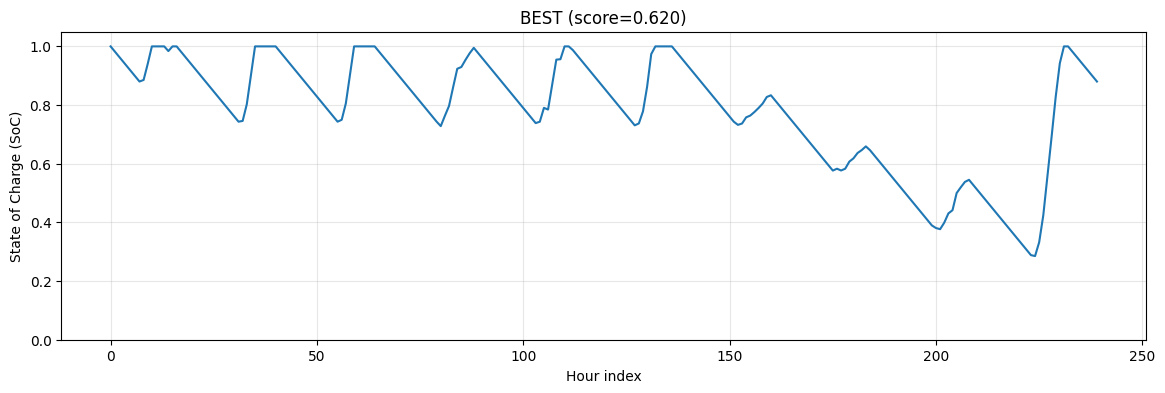

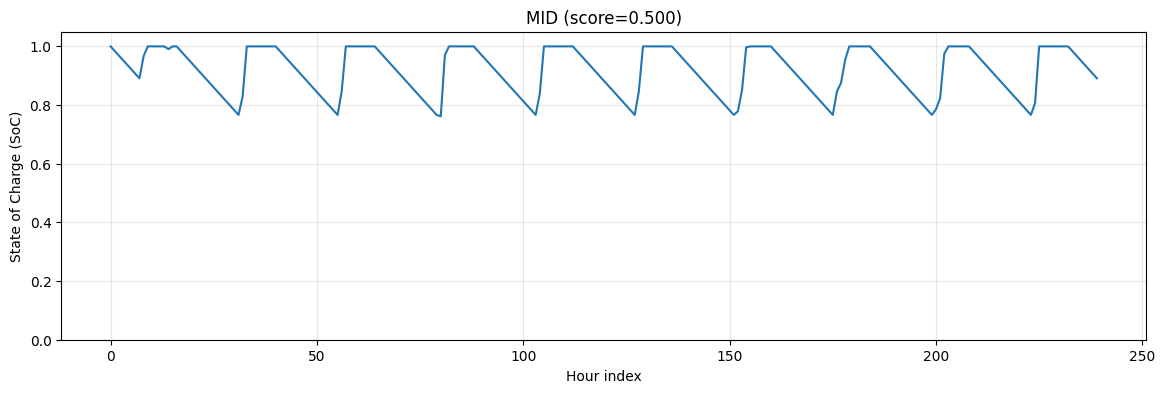

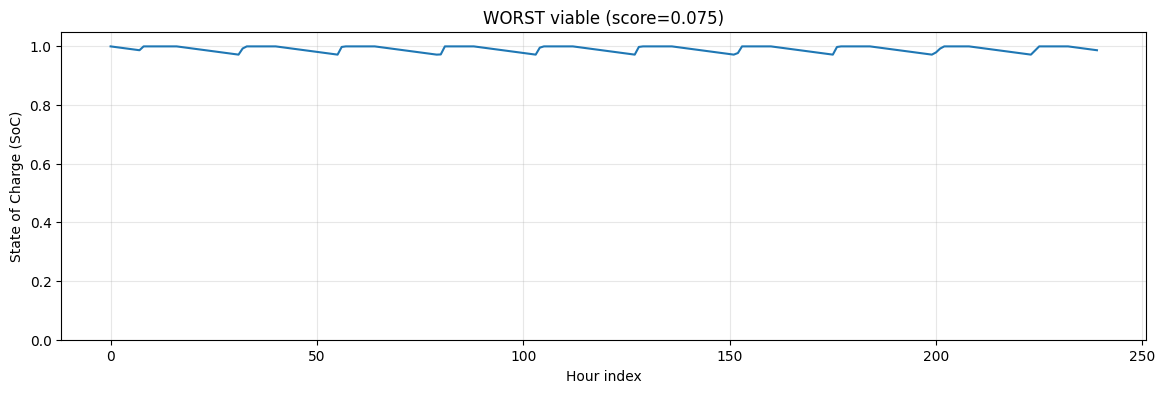

In [82]:
# BEST SCORE
plot_soc(
    df_soc,
    cfg_best["panel_area_m2"],
    cfg_best["C_batt_Ah"],
    cfg_best["eta_PMU"],
    title=f"BEST (score={cfg_best['score']:.3f})"
)

# MID SCORE (~0.5)
plot_soc(
    df_soc,
    cfg_mid["panel_area_m2"],
    cfg_mid["C_batt_Ah"],
    cfg_mid["eta_PMU"],
    title=f"MID (score={cfg_mid['score']:.3f})"
)

# WORST NON-ZERO SCORE
plot_soc(
    df_soc,
    cfg_worst["panel_area_m2"],
    cfg_worst["C_batt_Ah"],
    cfg_worst["eta_PMU"],
    title=f"WORST viable (score={cfg_worst['score']:.3f})"
)


In [83]:
def get_config_trace(df_soc, panel, capacity, eta):
    """Filter df_soc for one configuration and return it sorted by hour_index."""
    cfg = df_soc[
        (df_soc["panel_area_m2"] == panel) &
        (df_soc["C_batt_Ah"] == capacity) &
        (df_soc["eta_PMU"] == eta)
    ].sort_values("hour_index")
    return cfg

def plot_soc_gh(cfg, df_pv, hours=240, title=None):
    """
    Plot SoC and irradiance (G_h) for a given configuration.
    """

    # Slice hours
    cfg_win = cfg[cfg["hour_index"] < hours]
    pv_win = df_pv[df_pv["panel_area_m2"] == cfg["panel_area_m2"].iloc[0]]
    pv_win = pv_win[pv_win["hour_index"] < hours]

    plt.figure(figsize=(14,5))

    # SoC (primary axis)
    plt.plot(cfg_win["hour_index"], cfg_win["SoC"], label="SoC", linewidth=2)

    # Irradiance (secondary axis)
    ax = plt.gca()
    ax2 = ax.twinx()
    ax2.plot(pv_win["hour_index"], pv_win["G_h"], color="orange", alpha=0.5, label="G_h (W/m²)")

    plt.title(title or "SoC + G_h")
    ax.set_xlabel("Hour index")
    ax.set_ylabel("SoC")
    ax2.set_ylabel("G_h (W/m²)")

    ax.grid(True, alpha=0.3)

    plt.show()

def plot_soc_ibatt(cfg, hours=240, title=None):
    """
    Plot SoC and battery current (I_BAT_A) for a given configuration.
    """

    cfg_win = cfg[cfg["hour_index"] < hours]

    plt.figure(figsize=(14,6))

    # SoC curve
    ax = plt.gca()
    ax.plot(cfg_win["hour_index"], cfg_win["SoC"], label="SoC", linewidth=2)

    # Battery current
    ax2 = ax.twinx()
    ax2.plot(cfg_win["hour_index"], cfg_win["I_BAT_A"],
             color="red", alpha=0.6, label="I_BAT_A")

    ax.set_xlabel("Hour index")
    ax.set_ylabel("SoC")
    ax2.set_ylabel("I_BAT_A (A)")

    plt.title(title or "SoC + battery current")
    ax.grid(True, alpha=0.3)

    plt.show()

def plot_daily(cfg, day_index=0, title=None):
    """
    Plot a single day (24 hours) of SoC.
    day_index = 0 means hours 0-23, 1 means 24-47, etc.
    """

    start = day_index * 24
    end = start + 24

    win = cfg[(cfg["hour_index"] >= start) & (cfg["hour_index"] < end)]

    plt.figure(figsize=(12,4))
    plt.plot(win["Hour"], win["SoC"], linewidth=2)
    plt.ylim(0,1.05)
    plt.grid(True, alpha=0.3)
    plt.xlabel("Hour of day")
    plt.ylabel("SoC")
    plt.title(title or f"SoC during day {day_index}")
    plt.show()

def plot_seasonal_soc(cfg):
    """
    Plot average SoC by season: Winter, Spring, Summer, Autumn.
    """

    # Month → Season mapping
    season = {
        12: "Winter", 1: "Winter", 2: "Winter",
        3: "Spring", 4: "Spring", 5: "Spring",
        6: "Summer", 7: "Summer", 8: "Summer",
        9: "Autumn", 10: "Autumn", 11: "Autumn",
    }

    df = cfg.copy()
    df["Season"] = df["Month"].map(season)

    season_avg = df.groupby("Season")["SoC"].mean().reindex(
        ["Winter","Spring","Summer","Autumn"]
    )

    plt.figure(figsize=(8,4))
    plt.bar(season_avg.index, season_avg.values)
    plt.ylim(0,1)
    plt.title("Average SoC by season")
    plt.ylabel("Average SoC")
    plt.show()


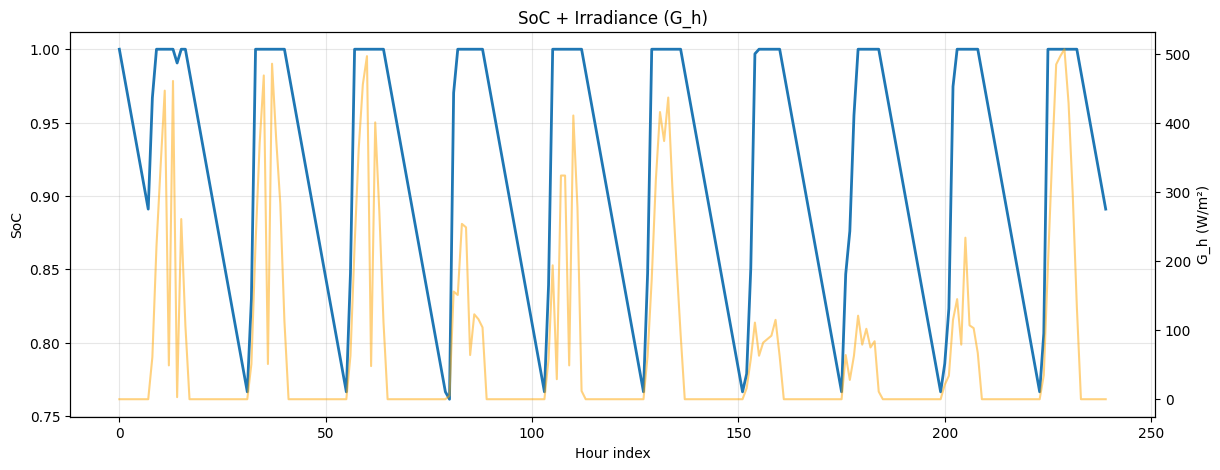

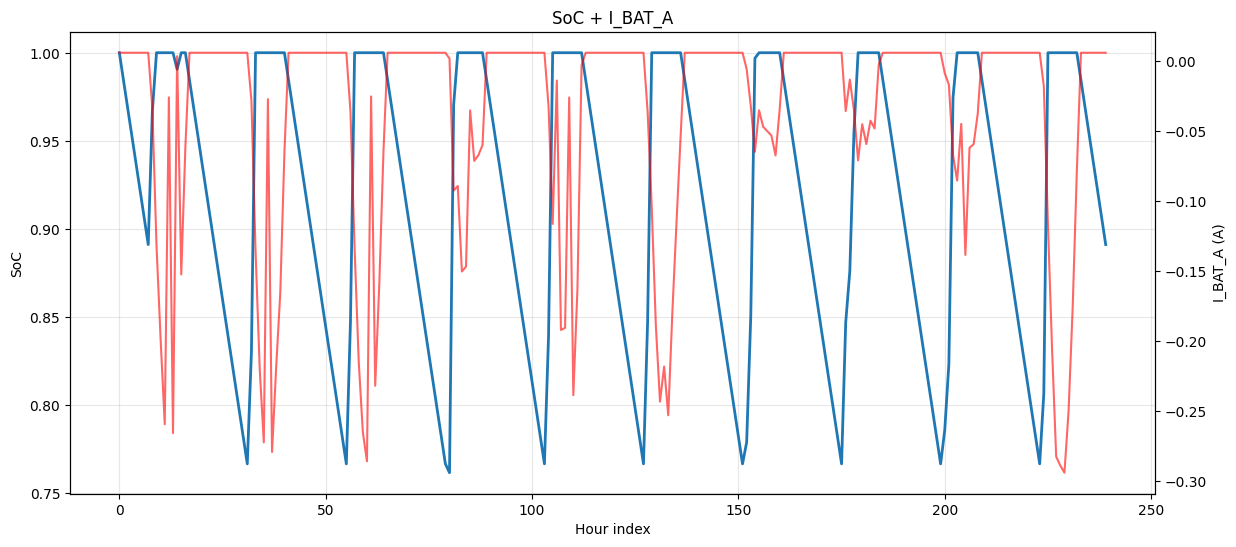

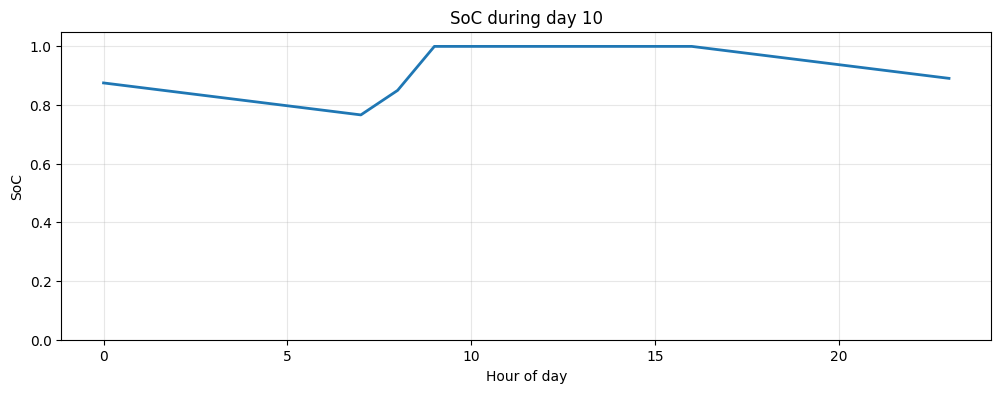

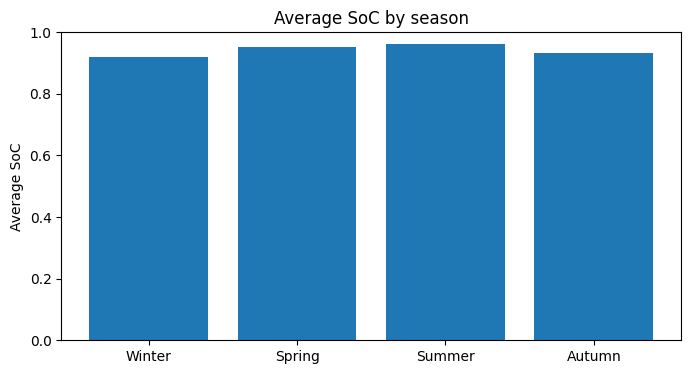

In [84]:
# Choose a configuration, e.g. cfg_mid (score ~0.5)
panel  = cfg_mid["panel_area_m2"]
cap    = cfg_mid["C_batt_Ah"]
eta    = cfg_mid["eta_PMU"]

cfg = get_config_trace(df_soc, panel, cap, eta)

plot_soc_gh(cfg, df_pv, hours=240, title="SoC + Irradiance (G_h)")
plot_soc_ibatt(cfg, hours=240, title="SoC + I_BAT_A")
plot_daily(cfg, day_index=10)
plot_seasonal_soc(cfg)


In [ ]:
import matplotlib.pyplot as plt

def plot_full_soc_analysis(df_soc, df_pv, panel, capacity, eta, hours=240, day_index=0):
    """
    Generate a 4-panel figure showing:
    1) SoC + Irradiance (G_h)
    2) SoC + Battery current (I_BAT_A)
    3) Daily SoC evolution (24 h)
    4) Seasonal average SoC

    Parameters
    ----------
    df_soc : DataFrame
        Simulation results with SoC and I_BAT_A.
    df_pv : DataFrame
        PV data with irradiance (G_h).
    panel : float
        Panel area (m2)
    capacity : float
        Battery capacity (Ah)
    eta : float
        PMU efficiency
    hours : int
        Number of hours to show in time-series plots (default 240 = 10 days)
    day_index : int
        Which day to plot (24h window)
    """

    # --- Select configuration ---
    cfg = df_soc[
        (df_soc["panel_area_m2"] == panel) &
        (df_soc["C_batt_Ah"] == capacity) &
        (df_soc["eta_PMU"] == eta)
    ].sort_values("hour_index")

    pv_cfg = df_pv[df_pv["panel_area_m2"] == panel]
    cfg_win = cfg[cfg["hour_index"] < hours]
    pv_win = pv_cfg[pv_cfg["hour_index"] < hours]

    # Day selection
    start = day_index * 24
    end = start + 24
    day = cfg[(cfg["hour_index"] >= start) & (cfg["hour_index"] < end)]

    # Season mapping
    season_map = {
        12:"Winter",1:"Winter",2:"Winter",
        3:"Spring",4:"Spring",5:"Spring",
        6:"Summer",7:"Summer",8:"Summer",
        9:"Autumn",10:"Autumn",11:"Autumn",
    }
    cfg["Season"] = cfg["Month"].map(season_map)
    season_avg = cfg.groupby("Season")["SoC"].mean().reindex(
        ["Winter","Spring","Summer","Autumn"]
    )

    # ---------------------------------------------------------
    # Create 4-panel figure
    # ---------------------------------------------------------
    fig, axs = plt.subplots(2, 2, figsize=(18, 10))
    (ax1, ax2), (ax3, ax4) = axs

    # ---------------------------------------------------------
    # 1) SoC + irradiance
    # ---------------------------------------------------------
    ax1.plot(cfg_win["hour_index"], cfg_win["SoC"], label="SoC", linewidth=2)
    ax1.set_ylabel("SoC")
    ax1.set_title("SoC + Irradiance (G_h)")
    ax1.grid(True, alpha=0.3)

    ax12 = ax1.twinx()
    ax12.plot(pv_win["hour_index"], pv_win["G_h"], color="orange", alpha=0.5, label="G_h")
    ax12.set_ylabel("G_h (W/m²)")

    # ---------------------------------------------------------
    # 2) SoC + battery current
    # ---------------------------------------------------------
    ax2.plot(cfg_win["hour_index"], cfg_win["SoC"], label="SoC", linewidth=2)
    ax2.set_ylabel("SoC")
    ax2.set_title("SoC + Battery Current (I_BAT_A)")
    ax2.grid(True, alpha=0.3)

    ax22 = ax2.twinx()
    ax22.plot(cfg_win["hour_index"], cfg_win["I_BAT_A"], color="red", alpha=0.5, label="I_BAT_A")
    ax22.set_ylabel("I_BAT_A (A)")

    # ---------------------------------------------------------
    # 3) Daily SoC profile
    # ---------------------------------------------------------
    ax3.plot(day["Hour"], day["SoC"], linewidth=2)
    ax3.set_title(f"SoC during Day {day_index}")
    ax3.set_xlabel("Hour of day")
    ax3.set_ylabel("SoC")
    ax3.grid(True, alpha=0.3)

    # ---------------------------------------------------------
    # 4) Seasonal average SoC
    # ---------------------------------------------------------
    ax4.bar(season_avg.index, season_avg.values)
    ax4.set_ylim(0, 1)
    ax4.set_title("Average SoC by Season")
    ax4.set_ylabel("Average SoC")

    # Global title
    fig.suptitle(
        f"SoC Analysis — Panel={panel} m², Battery={capacity} Ah, η={eta}",
        fontsize=16
    )

    plt.tight_layout()
    plt.show()


In [87]:
# Sort all configurations by score
summary_sorted = summary.sort_values("score", ascending=False)

# 1) Best score
cfg_best = summary_sorted.iloc[0]

# 2) Worst non-zero score
cfg_worst = summary_sorted[summary_sorted["score"] > 0].sort_values("score").iloc[0]

# 3) Score closest to 0.5
target_score = 0.5
idx_mid = (summary["score"] - target_score).abs().idxmin()
cfg_mid = summary.loc[idx_mid]

print("\nBEST:",  cfg_best[["panel_area_m2","C_batt_Ah","eta_PMU","score"]])
print("\nMID:",   cfg_mid[["panel_area_m2","C_batt_Ah","eta_PMU","score"]])
print("\nWORST:", cfg_worst[["panel_area_m2","C_batt_Ah","eta_PMU","score"]])



BEST: panel_area_m2    0.00250
C_batt_Ah        0.35000
eta_PMU          0.95000
score            0.62023
Name: 0, dtype: float64

MID: panel_area_m2    0.016000
C_batt_Ah        0.420000
eta_PMU          0.870000
score            0.499909
Name: 101, dtype: float64

WORST: panel_area_m2    0.031000
C_batt_Ah        3.200000
eta_PMU          0.950000
score            0.075188
Name: 365, dtype: float64


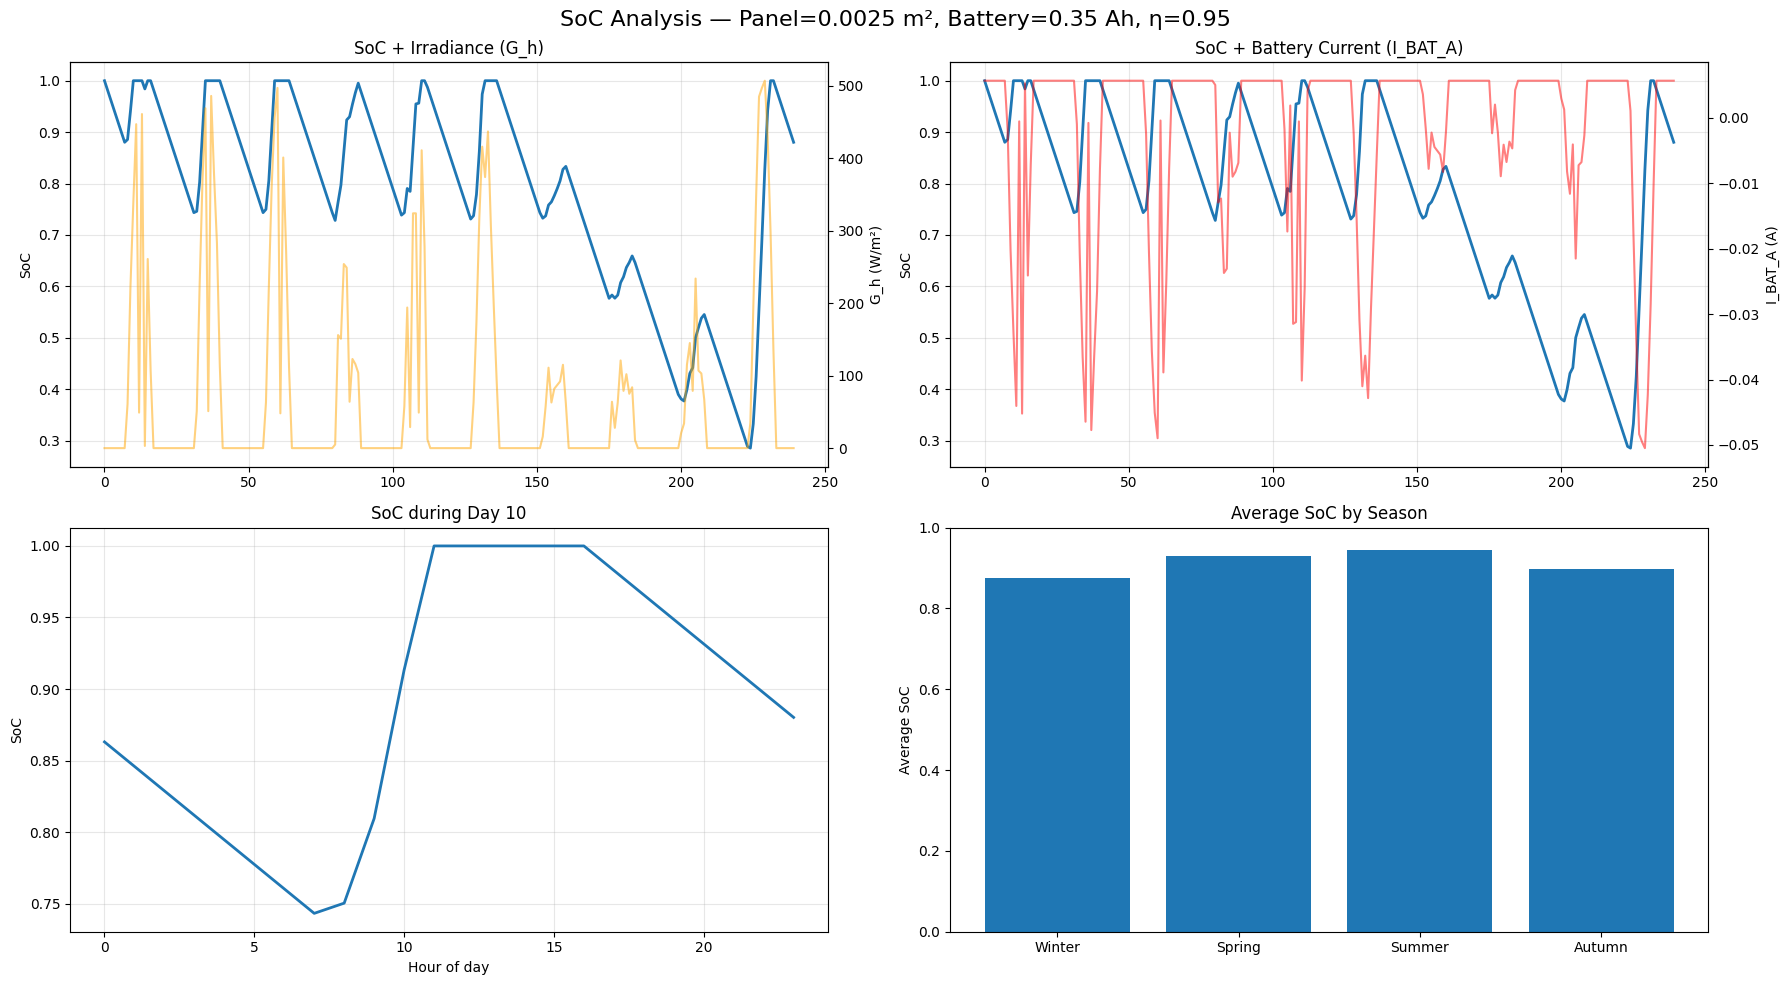

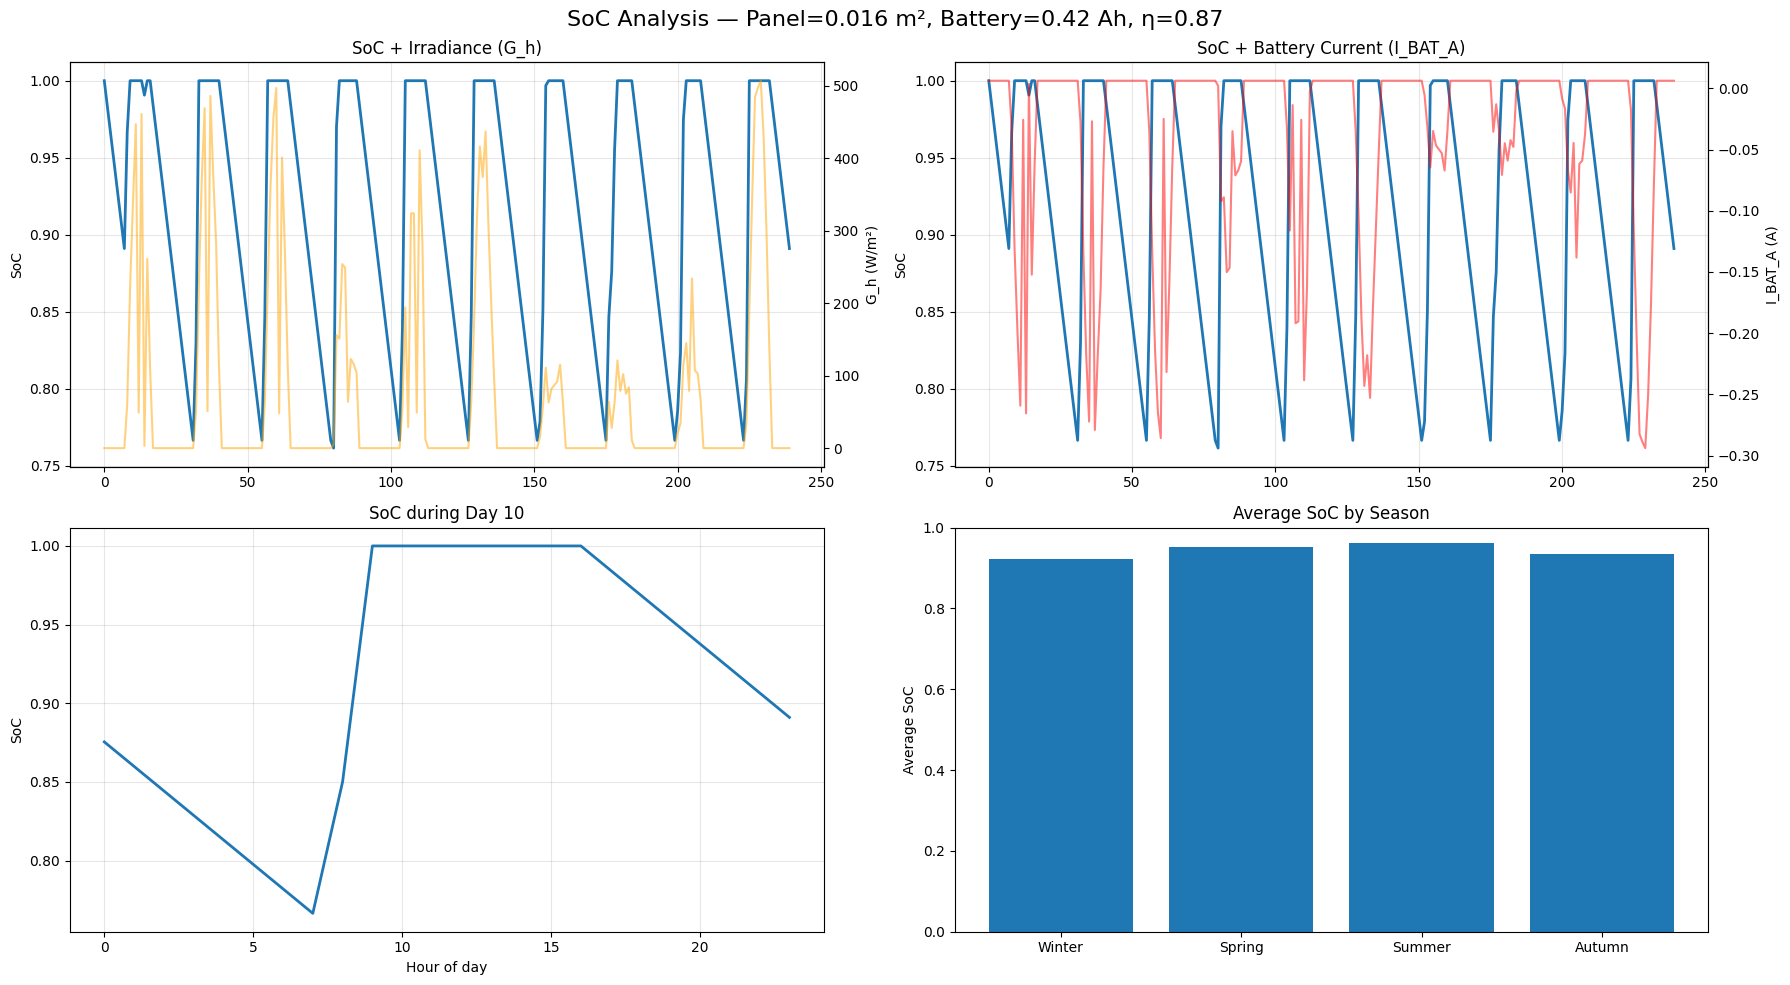

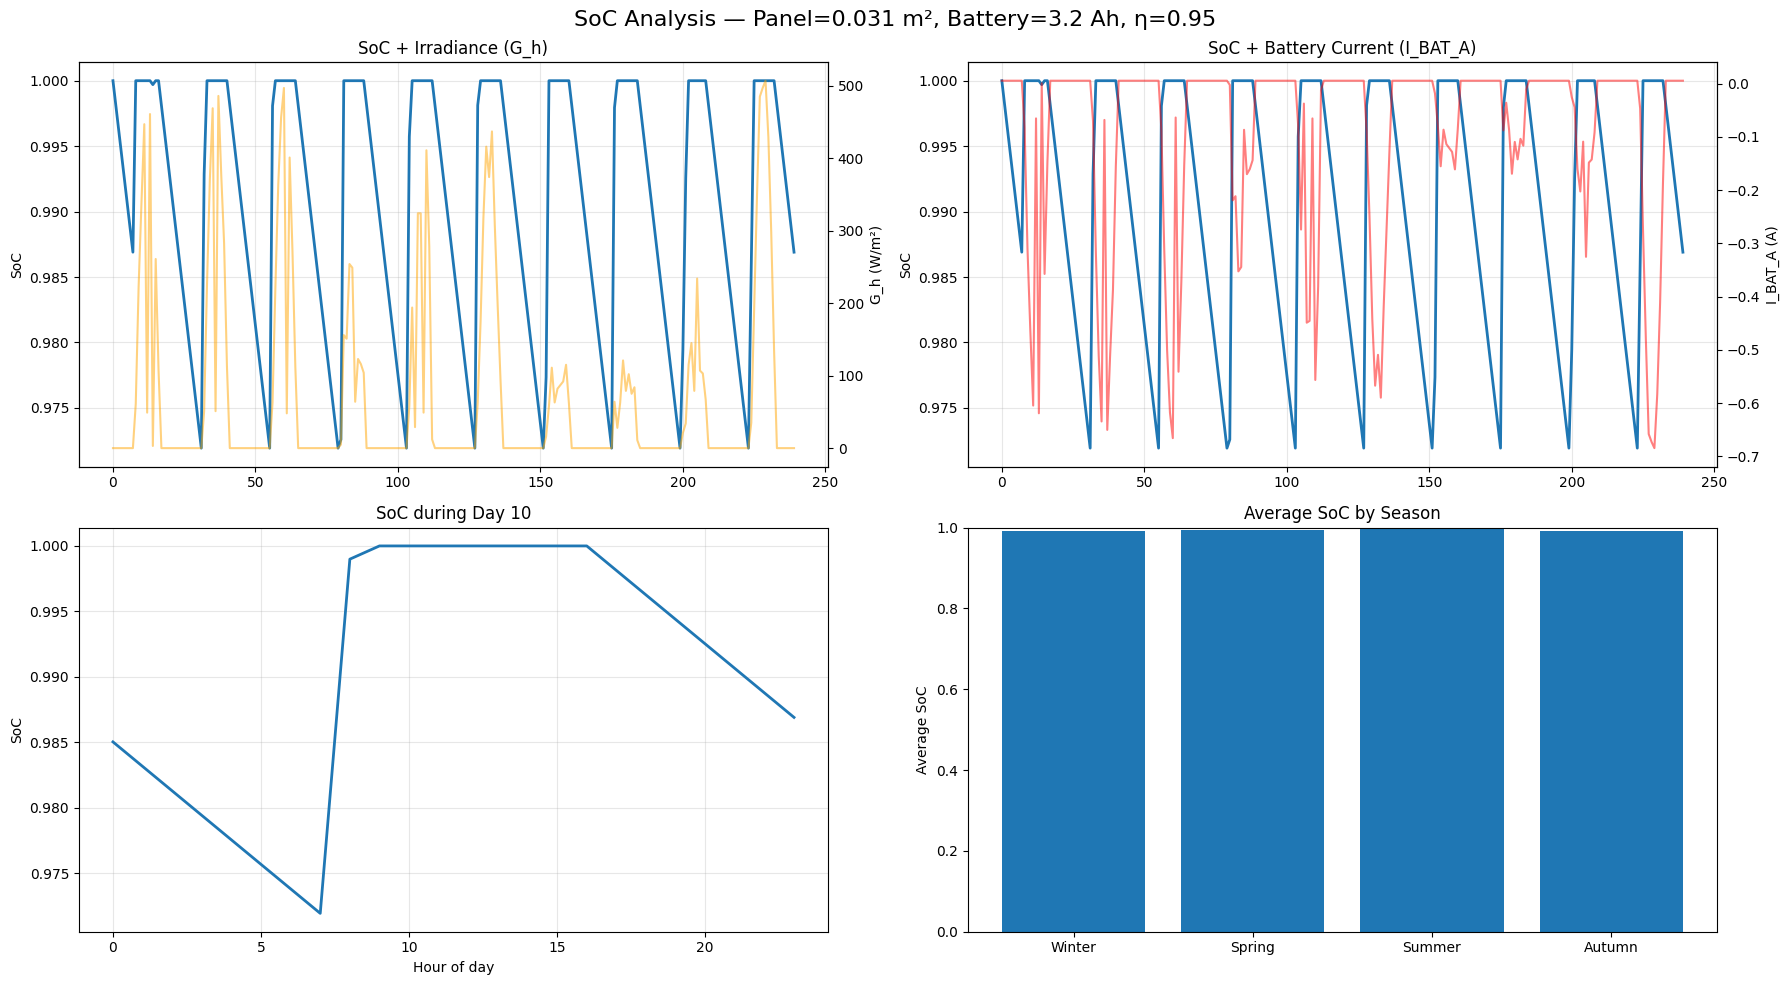

In [88]:
# === BEST SCORE ===
plot_full_soc_analysis(
    df_soc, df_pv,
    cfg_best["panel_area_m2"],
    cfg_best["C_batt_Ah"],
    cfg_best["eta_PMU"],
    hours=240,
    day_index=10
)

# === MID-SCORE (~0.5) ===
plot_full_soc_analysis(
    df_soc, df_pv,
    cfg_mid["panel_area_m2"],
    cfg_mid["C_batt_Ah"],
    cfg_mid["eta_PMU"],
    hours=240,
    day_index=10
)

# === WORST NON-ZERO SCORE ===
plot_full_soc_analysis(
    df_soc, df_pv,
    cfg_worst["panel_area_m2"],
    cfg_worst["C_batt_Ah"],
    cfg_worst["eta_PMU"],
    hours=240,
    day_index=10
)
